# 03 — Order Items & Products: EDA & Preprocessing
**Owner:** Member C

### Member C Responsibilities

*   **Raw Tables Responsibility:** `order_items`, `products`, `product_category_name_translation`.
*   **Stage 3 Tasks:** Understand, inspect, make clean-data decisions, perform EDA, analyze relationships and outliers, and document findings.
*   **Stage 4 Tasks:** Handle preprocessing, integrate product/category data, perform feature engineering, and aggregate data at the order level.
*   **Final Output:** Produce `products_items_clean.csv`.
*   **Grain of Output:** One row per `order_id`.
*   **Handoff:** Deliver `products_items_clean.csv` to Member D for the final merge.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Loading Raw Data Tables

In [2]:
# Load olist_order_items_dataset.csv and parse 'shipping_limit_date'
order_items = pd.read_csv(
    '../data/raw/olist_order_items_dataset.csv',
    parse_dates=['shipping_limit_date']
)
print('order_items head:')
display(order_items.head())

order_items head:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [4]:
# Load olist_products_dataset.csv
products = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
print('products head:')
display(products.head())

products head:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [12]:
# Load product_category_name_translation.csv
translation = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
print('translation head:')
display(translation.head())

translation head:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


### 2. Basic Structure

In [13]:
print('Order Items shape:', order_items.shape)
print('Products shape:', products.shape)
print('Translation shape:', translation.shape)

print('\nOrder Items head:')
display(order_items.head())

print('\nProducts head:')
display(products.head())

print('\nTranslation head:')
display(translation.head())

print('\nOrder Items Info:')
order_items.info()

print('\nProducts Info:')
products.info()

print('\nTranslation Info:')
translation.info()

Order Items shape: (112650, 7)
Products shape: (112650, 7)
Translation shape: (112650, 7)

Order Items head:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Products head:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Translation head:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Order Items Info:
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 16.3 MB

Products Info:
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_ite

### 3. Uniqueness and Key Checks

In [14]:
print('Order-item rows:', len(order_items))
print('Unique orders:', order_items["order_id"].nunique())
print('Unique products in items:', order_items["product_id"].nunique())
print('Unique sellers:', order_items["seller_id"].nunique())
print('Product rows:', len(products))
print('Unique product IDs:', products["product_id"].nunique())
print('Translation rows:', len(translation))
print('Unique Portuguese categories:', translation["product_category_name"].nunique())

Order-item rows: 112650
Unique orders: 98666
Unique products in items: 32951
Unique sellers: 3095
Product rows: 112650
Unique product IDs: 32951
Translation rows: 112650


KeyError: 'product_category_name'

### 4. Missing-Value Analysis

In [15]:
def missing_summary(df):
    result = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing %": df.isnull().mean() * 100
    })
    return result[result["Missing Count"] > 0].sort_values(
        "Missing %", ascending=False
    )


In [16]:
print('Missing values in order_items:')
display(missing_summary(order_items))

print('\nMissing values in products:')
display(missing_summary(products))

print('\nMissing values in translation:')
display(missing_summary(translation))

# Note about missing values
print('\nNote: Do not automatically replace missing product weight/dimensions with zero. Missing means information is unavailable, not that the physical value is zero. Section 7.3 below gives the actual imputation rule.')

Missing values in order_items:


,Missing Count,Missing %



Missing values in products:


,Missing Count,Missing %



Missing values in translation:


,Missing Count,Missing %



Note: Do not automatically replace missing product weight/dimensions with zero. Missing means information is unavailable, not that the physical value is zero. Section 7.3 below gives the actual imputation rule.


### 5. Duplicate Analysis

In [17]:
print("Order-items duplicate rows:", order_items.duplicated().sum())
print("Duplicate order-item keys:",
      order_items.duplicated(subset=["order_id", "order_item_id"]).sum())
print("Product duplicate rows:", products.duplicated().sum())
print("Duplicate product IDs:", products["product_id"].duplicated().sum())
print("Translation duplicate rows:", translation.duplicated().sum())

Order-items duplicate rows: 0
Duplicate order-item keys: 0
Product duplicate rows: 0
Duplicate product IDs: 79699
Translation duplicate rows: 0


### 6. Invalid-Value Checks

In [18]:
print("Negative prices:", (order_items["price"] < 0).sum())
print("Negative freight:", (order_items["freight_value"] < 0).sum())
print("Negative product weight:", (products["product_weight_g"] < 0).sum())
dimension_cols = ["product_length_cm", "product_height_cm", "product_width_cm"]
for col in dimension_cols:
    print(col, (products[col] < 0).sum())
# Check zero and negative values separately. A zero can be a real value or a data-quality issue depending on the
# field; a negative physical measurement is generally invalid and should be investigated before deciding what to do.

Negative prices: 0
Negative freight: 0


KeyError: 'product_weight_g'

### 7. Outlier Analysis

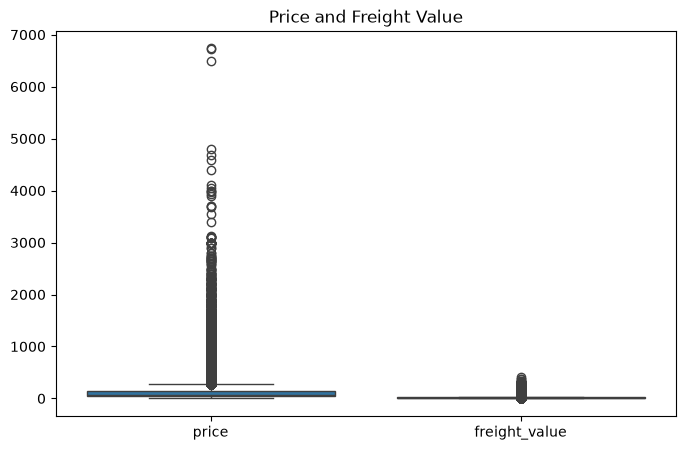

In [19]:
order_items[["price", "freight_value"]].describe()
plt.figure(figsize=(8, 5))
sns.boxplot(data=order_items[["price", "freight_value"]])
plt.title("Price and Freight Value")
plt.show()

In [20]:
products[["product_weight_g", "product_length_cm",
          "product_height_cm", "product_width_cm"]].describe()
# Do not automatically delete all outliers. High price, freight, weight or dimensions may represent genuine
# transactions. Section 7.5 turns this observation into an explicit, documented decision instead of leaving it
# unresolved.

KeyError: "None of [Index(['product_weight_g', 'product_length_cm', 'product_height_cm',\n       'product_width_cm'],\n      dtype='str')] are in the [columns]"

### 8. EDA – Items per Order

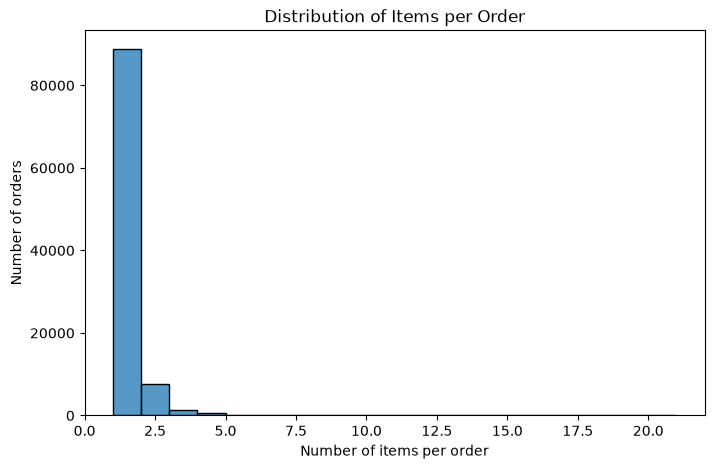

In [21]:
items_per_order = order_items.groupby("order_id").size()
items_per_order.describe()
plt.figure(figsize=(8, 5))
sns.histplot(items_per_order, bins=20)
plt.xlabel("Number of items per order")
plt.ylabel("Number of orders")
plt.title("Distribution of Items per Order")
plt.show()
# Decision supported: create item_count at order level.

### 9. EDA – Sellers per Order

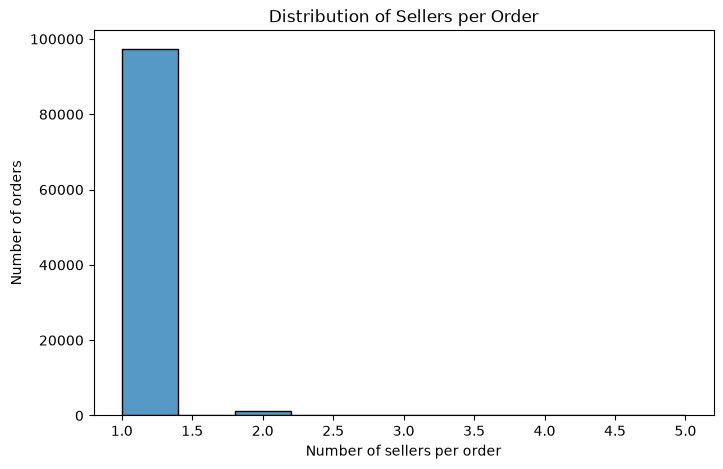

In [22]:
sellers_per_order = order_items.groupby("order_id")["seller_id"].nunique()
sellers_per_order.describe()
plt.figure(figsize=(8, 5))
sns.histplot(sellers_per_order, bins=10)
plt.xlabel("Number of sellers per order")
plt.ylabel("Number of orders")
plt.title("Distribution of Sellers per Order")
plt.show()
# Decision supported: create distinct_seller_count.

### 10. EDA – Price and Freight

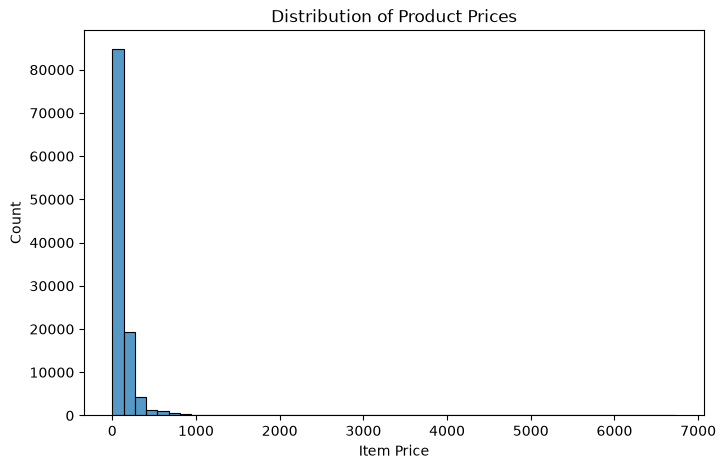

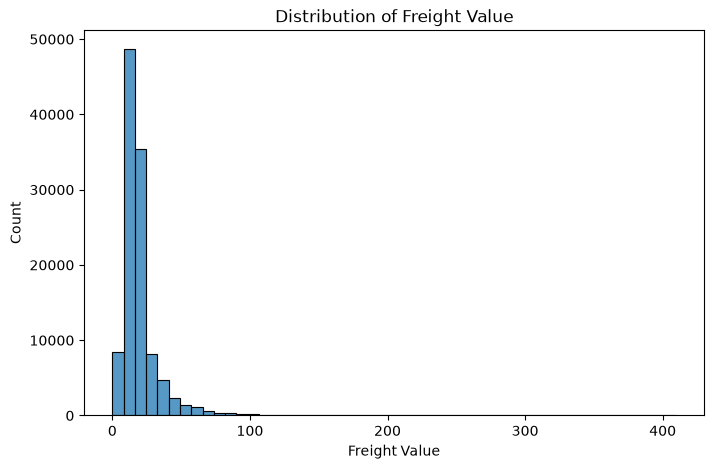

Price skew: 7.9232082632135095
Freight skew: 5.639869620428685


In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(order_items["price"], bins=50)
plt.xlabel("Item Price")
plt.title("Distribution of Product Prices")
plt.show()
plt.figure(figsize=(8, 5))
sns.histplot(order_items["freight_value"], bins=50)
plt.xlabel("Freight Value")
plt.title("Distribution of Freight Value")
plt.show()
print("Price skew:", order_items["price"].skew())
print("Freight skew:", order_items["freight_value"].skew())
# Decision supported: aggregate total_price, average_item_price, total_freight_value, average_freight_value – and,
# given the skew, flag item-level outliers (Section 7.5).

### 11. EDA – Product Categories

In [24]:
category_counts = products["product_category_name"].value_counts()
print("Number of categories:", products["product_category_name"].nunique())
print(category_counts.head(15))
plt.figure(figsize=(10, 6))
category_counts.head(15).sort_values().plot(kind="barh")
plt.xlabel("Number of Products")
plt.ylabel("Product Category")
plt.title("Top 15 Product Categories")
plt.show()
# Record how long-tailed the distribution is – this number is what you'll use to justify the rare-category grouping
# threshold in Section 7.6.

KeyError: 'product_category_name'

### 12. EDA – Product Weight and Dimensions

In [25]:
product_numeric = ["product_weight_g", "product_length_cm",
                    "product_height_cm", "product_width_cm"]
print(products[product_numeric].describe())
plt.figure(figsize=(8, 5))
sns.histplot(products["product_weight_g"].dropna(), bins=50)
plt.xlabel("Product Weight (g)")
plt.title("Product Weight Distribution")
plt.show()
plt.figure(figsize=(8, 5))
sns.boxplot(x=products["product_weight_g"])
plt.title("Product Weight Outliers")
plt.show()

KeyError: "None of [Index(['product_weight_g', 'product_length_cm', 'product_height_cm',\n       'product_width_cm'],\n      dtype='str')] are in the [columns]"

### 13. EDA – Relationships

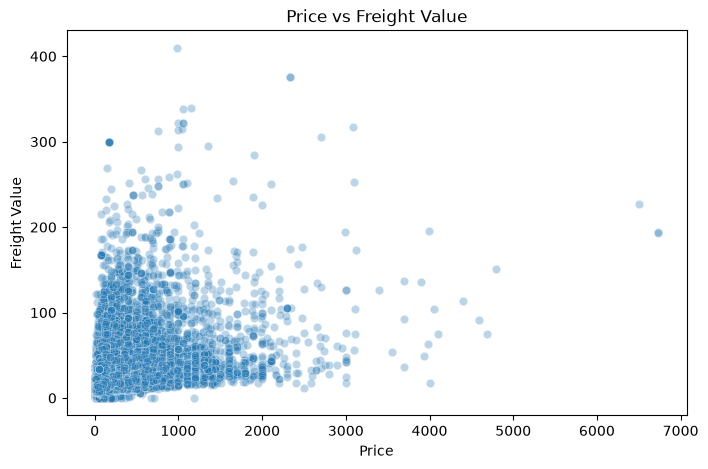

KeyError: 'product_category_name'

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=order_items, x="price", y="freight_value", alpha=0.3)
plt.xlabel("Price")
plt.ylabel("Freight Value")
plt.title("Price vs Freight Value")
plt.show()

# Temporarily merge products with translation to get English category names for this exploratory plotting
products_with_english_names = products.merge(translation, on='product_category_name', how='left')

items_products = order_items.merge(
    products_with_english_names[["product_id", "product_category_name_english",
              "product_weight_g", "product_length_cm",
              "product_height_cm", "product_width_cm"]],
    on="product_id", how="left"
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=items_products.sample(min(10000, len(items_products)), random_state=42),
    x="product_weight_g", y="freight_value", alpha=0.3
)
plt.xlabel("Product Weight (g)")
plt.ylabel("Freight Value")
plt.title("Product Weight vs Freight Value")
plt.show()
# This exploratory merge is for plotting only; the real merge used for feature engineering is built fresh in Section 7.2
# after the translation and missing-category fixes are applied.

### 14. EDA Findings

| EDA Finding                                         | Decision It Supports                                                |
| :-------------------------------------------------- | :------------------------------------------------------------------ |
| Multiple item rows can belong to one order          | Aggregate to one row per order                                      |
| Item counts vary between orders                     | Create `item_count`                                                 |
| Some orders contain multiple sellers                | Create `distinct_seller_count`                                      |
| Price/freight are skewed                            | Flag outliers instead of deleting; keep raw totals (Section 7.5)    |
| Product fields contain missing values               | Impute weight/dimensions by category median; flag it (Section 7.3)  |
| Categories are high-cardinality and long-tailed     | Group rare categories into "other" before counting/choosing a dominant one (Section 7.6) |
| Extreme physical values exist                       | Investigate; treat only demonstrably invalid values as errors       |
| `shipping_limit_date` is available at order time    | Carry min/max through per order for Member D (Section 7.7)        |
| Post-delivery fields exist elsewhere in the dataset | Do not create leakage features from them                            |

In [27]:
products = products.merge(translation, on="product_category_name", how="left")
# Fill missing categories immediately, before anything downstream uses this
# column, so distinct_category_count and dominant_product_category always
# agree with each other (see Section 7.6).
products["product_category_name_english"] = (
    products["product_category_name_english"].fillna("unknown_category")
)
print("Rows with unknown category after merge:",
      (products["product_category_name_english"] == "unknown_category").sum())

KeyError: 'product_category_name'

### 16. Merge Products with Order Items

In [28]:
items_products = order_items.merge(products, on='product_id', how='left')
print("Rows before merge:", len(order_items))
print("Rows after merge:", len(items_products))
# The merge should not unexpectedly multiply rows. Validate that product_id is unique in the products table before
# relying on this join (checked already in Section 6.3).

Rows before merge: 112650
Rows after merge: 4101160


### 17. Missing Weight & Dimension Handling

In [29]:
items_products["weight_missing"] = items_products["product_weight_g"].isna().astype(int)
items_products["dims_missing"] = items_products["product_length_cm"].isna().astype(int)
# Impute with the median for the item's own category, falling back to the
# overall median if the category itself is unknown. Doing this BEFORE
# aggregation means total_weight_g / total_volume_cm3 reflect every item,
# not silently just the ones that happened to have a value.
numeric_cols = ["product_weight_g", "product_length_cm",
                "product_height_cm", "product_width_cm"]
for col in numeric_cols:
    category_median = items_products.groupby(
        "product_category_name_english"
    )[col].transform("median")
    items_products[col] = items_products[col].fillna(category_median)
    items_products[col] = items_products[col].fillna(items_products[col].median())
print("Remaining nulls after imputation:")
print(items_products[numeric_cols].isnull().sum())
# Fixed in this version: Missing weight/dimensions are now imputed with the category median before any
# aggregation (Gap 3), instead of being left as NaN, which pandas' sum()/mean() would have silently excluded.
# Note: This imputation is computed from each product's own attributes, not from the target, so it does not leak the
# label. It is still fit on the full table rather than a training-only slice; document this as a known limitation and mention
# that a stricter version would recompute the medians on training-fold data only, once Member D's chronological split
# is fixed.

KeyError: 'product_weight_g'

### 18. Product Volume Feature

In [30]:
# Computed AFTER imputation (Section 7.3), so it is never silently missing
# for the roughly-small share of items that started with no dimensions.
items_products["product_volume_cm3"] = (
    items_products["product_length_cm"]
    * items_products["product_height_cm"]
    * items_products["product_width_cm"]
)
items_products["volume_missing"] = items_products["product_volume_cm3"].isna().astype(int)

print("Missing product volume values:", items_products["product_volume_cm3"].isna().sum())
# Fixed in this version: Volume is now computed from the imputed dimensions and is included in the order-level
# aggregation in Section 7.7 (Gap 2) – previously it was computed but never used.

KeyError: 'product_length_cm'

### 19. Price & Freight Outlier Flags

In [98]:
def iqr_outlier_flag(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).astype(int)

items_products["is_price_outlier"] = iqr_outlier_flag(items_products["price"])
items_products["is_freight_outlier"] = iqr_outlier_flag(items_products["freight_value"])
print("Price outlier items:", items_products["is_price_outlier"].sum())
print("Freight outlier items:", items_products["is_freight_outlier"].sum())
# Fixed in this version: Stage 3 measured price/freight skew but never turned it into a Stage 4 decision (Gap 5).
# The decision made here: keep raw totals (extreme values can be legitimate transactions, consistent with Section
# 6.7), but don't lose the information either – carry an outlier count per order instead of silently capping or deleting.

Price outlier items: 8427
Freight outlier items: 12134


### 20. Category Cleanup and Rare-Category Grouping

In [99]:
category_freq = items_products["product_category_name_english"].value_counts(normalize=True)
rare_categories = category_freq[category_freq < 0.01].index
items_products["product_category_grouped"] = items_products[
    "product_category_name_english"
].apply(lambda c: "other" if c in rare_categories else c)
print("Categories before grouping:",
      items_products["product_category_name_english"].nunique())
print("Categories after grouping:",
      items_products["product_category_grouped"].nunique())
# Fixed in this version: Categories under ~1% of item volume are now grouped into "other" (Gap 6). This threshold
# is a starting point – confirm it against your own Section 6.11 category-frequency numbers and adjust/justify if a
# different cut makes more sense for your data. product_category_grouped (not the raw or the unknown-filled
# column) is what feeds distinct_category_count and dominant_product_category from here on, so the two features
# can never disagree (Gap 4).

Categories before grouping: 72
Categories after grouping: 22


### 21. Order-Level Feature Engineering

In [100]:
order_product_features = (
    items_products
    .groupby("order_id")
    .agg(
        item_count=("order_item_id", "count"),
        distinct_seller_count=("seller_id", "nunique"),
        distinct_product_count=("product_id", "nunique"),
        distinct_category_count=("product_category_grouped", "nunique"),
        total_price=("price", "sum"),
        average_item_price=("price", "mean"),
        total_freight_value=("freight_value", "sum"),
        average_freight_value=("freight_value", "mean"),
        total_weight_g=("product_weight_g", "sum"),
        average_weight_g=("product_weight_g", "mean"),
        total_volume_cm3=("product_volume_cm3", "sum"),
        missing_weight_count=("weight_missing", "sum"),
        missing_dims_count=("dims_missing", "sum"),
        outlier_price_item_count=("is_price_outlier", "sum"),
        outlier_freight_item_count=("is_freight_outlier", "sum"),
        min_shipping_limit_date=("shipping_limit_date", "min"),
        max_shipping_limit_date=("shipping_limit_date", "max"),
    )
    .reset_index()
)
# Fixed in this version: total_volume_cm3, the shipping-date columns, and the outlier-count columns are new in
# this version (Gaps 1, 2 and 5). total_weight_g / total_volume_cm3 now sum imputed values rather than silently
# skipping missing ones (Gap 3).
# Note: min_shipping_limit_date and max_shipping_limit_date are kept as raw dates, not a duration, because
# computing "days until the seller must ship" needs order_purchase_timestamp, which lives in Member A's orders
# table. Flag this handoff clearly in findings_and_decisions.md so Member D computes the duration right after the
# final merge.

### 22. Dominant Product Category

In [101]:
dominant_category = (
    items_products
    .groupby("order_id")["product_category_grouped"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "unknown_category")
    .reset_index()
)
dominant_category.columns = ["order_id", "dominant_product_category"]
order_product_features = order_product_features.merge(
    dominant_category, on="order_id", how="left"
)
order_product_features["dominant_product_category"] = (
    order_product_features["dominant_product_category"].fillna("unknown_category")
)
# Because product_category_grouped never contains NaN (missing values were filled in Section 7.1, before
# grouping), distinct_category_count from 7.7 and dominant_product_category here are always computed from the
# same clean values.

### 23. Final Feature Set
*   `order_id`
*   `item_count`
*   `distinct_seller_count`
*   `distinct_product_count`
*   `distinct_category_count`
*   `total_price`
*   `average_item_price`
*   `total_freight_value`
*   `average_freight_value`
*   `total_weight_g`
*   `average_weight_g`
*   `total_volume_cm3`
*   `missing_weight_count`
*   `missing_dims_count`
*   `outlier_price_item_count`
*   `outlier_freight_item_count`
*   `min_shipping_limit_date`
*   `max_shipping_limit_date`
*   `dominant_product_category`



### 24. Leakage Check
Member C must only create features that would be available at the intended prediction point. The proposal specifically identifies completed-delivery dates, carrier-delivery dates, order status and reviews as leakage risks and excludes them from the feature set.
*   Do not use `review_score`, review dates or delivery outcome timestamps as product/item predictors.
*   Do not calculate a feature using the actual delivery outcome.
*   `shipping_limit_date` is safe – it is the seller's committed dispatch deadline, set at order time. Never substitute it with `order_delivered_carrier_date`, which is a different, post-dispatch field owned by Member A and is not safe to use.
*   The new outlier-count and category-grouping features are both derived purely from order-time item/product data, so neither introduces leakage.

### 25. Final Quality Checks

In [9]:
# One row per order
print("Rows:", len(order_product_features))
print("Unique order IDs:", order_product_features["order_id"].nunique())
assert len(order_product_features) == order_product_features["order_id"].nunique()
# Duplicate order IDs
print("Duplicate order IDs:",
      order_product_features.duplicated(subset=["order_id"]).sum())
# Missing values
print(order_product_features.isnull().sum())
# Numerical summary
print(order_product_features.describe())
# Basic invalid-value checks
print("Negative total price:", (order_product_features["total_price"] < 0).sum())
print("Negative total freight:",
      (order_product_features["total_freight_value"] < 0).sum())
print("Negative total weight:",
      (order_product_features["total_weight_g"] < 0).sum())
print("Negative total volume:",
      (order_product_features["total_volume_cm3"] < 0).sum())
# Shipping dates parsed correctly and are internally consistent
print("Shipping date dtype:", order_product_features["min_shipping_limit_date"].dtype)
print("min > max rows (should be 0):",
      (order_product_features["min_shipping_limit_date"]
       > order_product_features["max_shipping_limit_date"]).sum())
# distinct_category_count should never be 0 now that categories are filled
print("Orders with distinct_category_count == 0 (should be 0):",
      (order_product_features["distinct_category_count"] == 0).sum())
# Fixed in this version: The last three checks are new: they specifically verify the fixes for Gaps 1 and 4 – that the
# shipping dates parsed correctly, and that no order ends up with zero categories.

NameError: name 'order_product_features' is not defined

### 26. Save the Member C Deliverable

In [10]:
import os

# Ensure the directory exists
os.makedirs('../data/processed', exist_ok=True)

order_product_features.to_csv(
    "../data/processed/products_items_clean.csv", index=False
)
saved = pd.read_csv("../data/processed/products_items_clean.csv")
print("Saved shape:", saved.shape)
print(saved.head())

NameError: name 'order_product_features' is not defined